Alumno: Ricardo Benalcazar
Curso: CDDEIA-ELMA-4-1

In [18]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

**Naive Bayes Gaussiano**

In [2]:
datos=load_breast_cancer()
X = datos.data
y = datos.target
X_train, X_test, y_train, y_test = train_test_split(datos.data, datos.target, test_size=0.2, random_state=24)

modelo = GaussianNB()
modelo.fit(X_train, y_train)
y_pred=modelo.predict(X_test)
print("Accuracy del Gaussian NB: ",accuracy_score(y_test, y_pred))

Accuracy del Gaussian NB:  0.9210526315789473


In [11]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9444444444444444
Recall: 0.9315068493150684
F1 Score: 0.9379310344827586


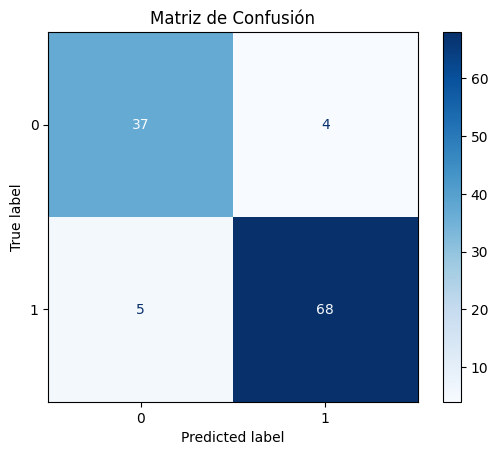

In [20]:
matriz_confusion = confusion_matrix(y_test, y_pred)

displayser = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
displayser.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

El modelo tuvo una precision de 94.4%, el recall indica que tan bien identifica los casos positivos reales en este caso fue de un 93.2%, y tambien está el F1-Score que mide el balance entre precision y sensibilidad en este caso de un 93.8%. La matriz de confusión muestra pocos errores, por lo cual se podria decir que el modelo es preciso y balanceado.

**Naive Bayes Multinomial**

In [3]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
categorias = [
    "sci.space",
    "rec.sport.baseball"
]
datos=fetch_20newsgroups(subset="train",categories=categorias)

vectorizador=CountVectorizer()
Xm=vectorizador.fit_transform(datos.data)
ym=datos.target

In [7]:
X_trainM, X_testM, y_trainM, y_testM=train_test_split(Xm,ym,test_size=0.3,random_state=24)
modeloM=MultinomialNB()
modeloM.fit(X_trainM,y_trainM)
y_predM=modeloM.predict(X_testM)
print("Accuracy del Multinomial NB: ",accuracy_score(y_testM, y_predM))

Accuracy del Multinomial NB:  0.9971988795518207


In [22]:
precision = precision_score(y_testM, y_predM)
recall = recall_score(y_testM, y_predM)
f1 = f1_score(y_testM, y_predM)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 1.0
Recall: 0.9941176470588236
F1 Score: 0.9970501474926253


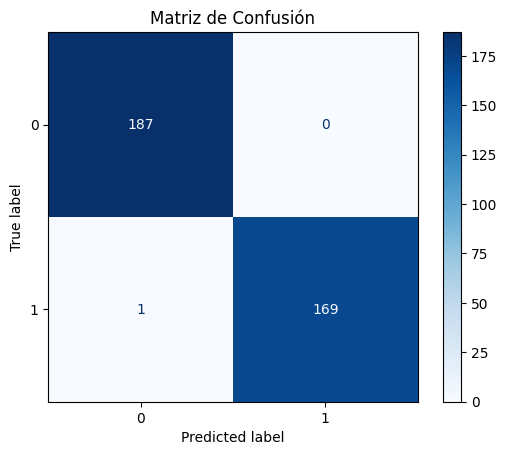

In [25]:
matriz_confusion = confusion_matrix(y_testM, y_predM)

displayser = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
displayser.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()


El modelo tuvo un rendimiento casi perfecto con una precision de 1.0, el recall indica que tan bien identifica los casos positivos reales en este caso fue de un 99.4%, y tambien está el F1-Score que mide el balance entre precision y sensibilidad en este caso de un 99.7%. La matriz de confusión muestra que clasificó 356 casos de 357 correctamente, lo cual demuestra una alta capacidad del modelo.  

**Naive Bayes Bernoulli**

In [8]:
modeloB=BernoulliNB()
modeloB.fit(X=X_trainM,y=y_trainM)
y_pred_3=modeloB.predict(X_testM)
print("Accuracy del Bernoulli NB: ",accuracy_score(y_testM, y_pred_3))

Accuracy del Bernoulli NB:  0.9159663865546218


In [26]:
precision = precision_score(y_testM, y_pred_3)
recall = recall_score(y_testM, y_pred_3)
f1 = f1_score(y_testM, y_pred_3)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9929577464788732
Recall: 0.8294117647058824
F1 Score: 0.9038461538461539


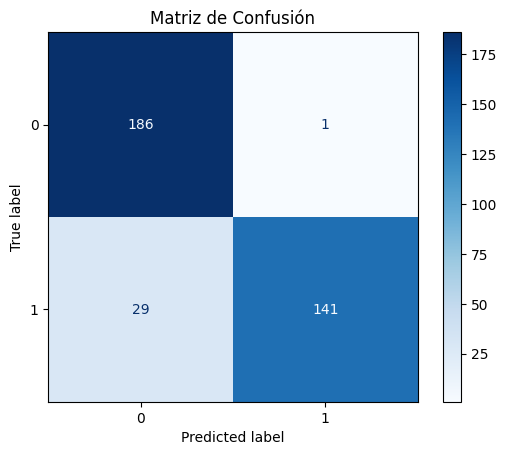

In [27]:
matriz_confusion = confusion_matrix(y_testM, y_pred_3)

displayser = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion)
displayser.plot(cmap="Blues")
plt.title("Matriz de Confusión")
plt.show()

El modelo tuvo una precision de 99.3%, el recall indica que tan bien identifica los casos positivos reales en este caso fue de un 82.9%, y tambien está el F1-Score que mide el balance entre precision y sensibilidad en este caso de un 90.4%. La matriz de confusión muestra que el modelo si acertó en la mayoria de casos pero tiene errores al tener 29 falsos negativos, lo que indica que el modelo aun no identifica bien al menos una de las clases.